In [26]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
# from dataset.mnist import load_mnist
# from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [27]:
test_dict = {}
train_dict = {}
root_path = '../datasets/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) shape, run following codes.
def numpy2rgb(arr: np.ndarray) -> np.ndarray:
    batch_size = len(arr)
    arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [28]:
x_train, t_train = train_dict[b'data'], train_dict[b'labels']
x_test, t_test = test_dict[b'data'], test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 32, 32, 3)
255
(50000,)


In [29]:
r_channel = x_train[..., 0]
g_channel = x_train[..., 1]
b_channel = x_train[..., 2]

all_channel = r_channel
all_channel.shape

(50000, 32, 32)

In [30]:
all_channel_accum = np.sum(all_channel, axis=0)

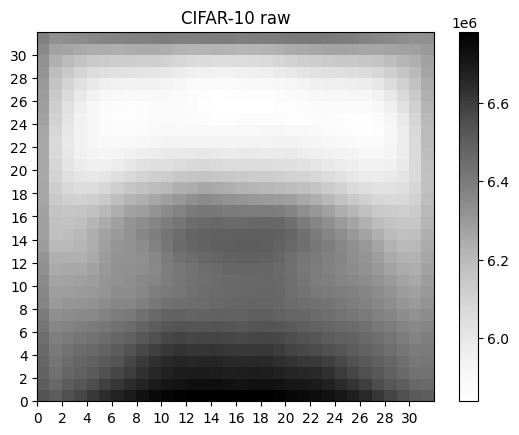

In [31]:
plt.pcolor(all_channel_accum, cmap='Greys')
plt.xticks(range(0,32,2))
plt.yticks(range(0,32,2))
plt.title('CIFAR-10 raw')
plt.colorbar()
plt.show()

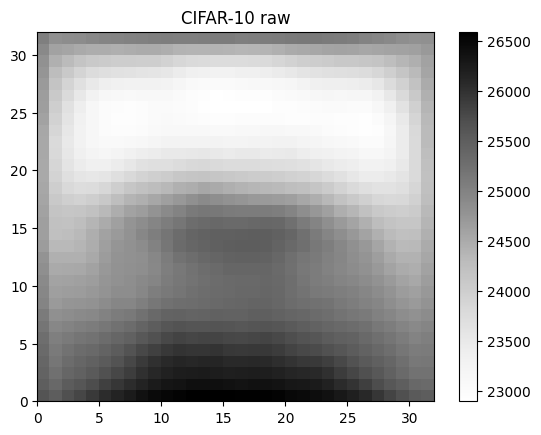

In [32]:
all_channel_accum = np.sum(all_channel, axis=0) / 255.0

plt.pcolor(all_channel_accum, cmap='Greys')
# plt.xticks(range(0,32,2))
# plt.yticks(range(0,32,2))
plt.title('CIFAR-10 raw')
plt.colorbar()
plt.show()

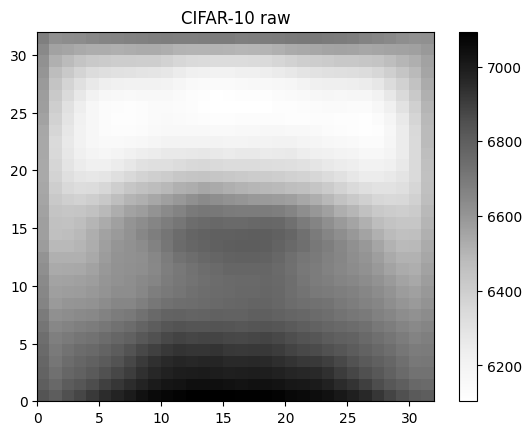

In [33]:
all_channel_accum = (np.sum(all_channel, axis=0) - np.mean(all_channel_accum)) / np.std(all_channel_accum)

plt.pcolor(all_channel_accum, cmap='Greys')
# plt.xticks(range(0,32,2))
# plt.yticks(range(0,32,2))
plt.title('CIFAR-10 raw')
plt.colorbar()
plt.show()